# Setup

In [1]:
import shutil, os
if os.path.exists('e_network_inequality'):
    shutil.rmtree('e_network_inequality')

# !git clone https://github.com/IgnacioOQ/e_network_inequality
!git clone -b main https://github.com/IgnacioOQ/e_network_inequality

Cloning into 'e_network_inequality'...
remote: Enumerating objects: 11254, done.
remote: Counting objects: 100% (468/468), done.
remote: Compressing objects: 100% (305/305), done.
remote: Total 11254 (delta 212), reused 198 (delta 162), pack-reused 10786 (from 2)
Receiving objects: 100% (11254/11254), 552.00 MiB | 59.47 MiB/s, done.
Resolving deltas: 100% (5924/5924), done.


In [2]:
!pip install dill

In [3]:
%cd e_network_inequality

/content/e_network_inequality


In [4]:
import sys, os
sys.path.insert(0, os.getcwd())

from utils.imports import *
from model.agents import BetaAgent, BayesAgent
from model.model import Model
from utils.network_utils import *
from networks.network_generation import *
from networks.variation_methods import *
from model.simulation_functions import *
from model.vectorized_simulation_functions import *
from functools import partial
import hashlib
import gc
from multiprocessing import get_context

In [5]:
from google.colab import drive
drive.mount('/content/drive')

dumping_path = '/content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/'
print("Current Directory:", dumping_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Directory: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/


In [6]:
def generate_parameters_here(_,G,method='randomization'):
    process_seed = int.from_bytes(os.urandom(4), byteorder='little')
    rd.seed(process_seed)
    # Randomly sample parameters for this group
    uncertainty = rd.uniform(.000001, .001)
    n_experiments = rd.randint(1000, 10000)
    # now we pick a random number
    # Capped at 1/3 to prevent "Sample larger than population" errors in equalize
    proportion_edges = rd.rand() * (1/3)
    # Do randomization
    num_edges = G.number_of_edges()
    if method == 'randomization':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = randomize_network(G, n_edges=num_edges_to_randomize)
    if method == 'equalize':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = equalize(G, num_edges_to_randomize)
    if method == 'densify':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='original',keep_density_fixed=False)
    if method == 'densify_fixed':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = densify_fancy_speed_up(G,num_edges_to_add,target_degree_dist='uniform',keep_density_fixed=True)
    if method =='cluster':
      num_edges_to_add = int(num_edges * proportion_edges)
      modified_network = cluster_network(G,num_edges_to_add)
    if method =='decluster':
      num_edges_to_randomize = int(num_edges * proportion_edges)
      modified_network = decluster_network(G,num_edges_to_randomize)

    result = generate_parameters_aggregate(modified_network, uncertainty=uncertainty, n_experiments=n_experiments,
                                           p_rewiring=proportion_edges)
    result['uncertainty'] = uncertainty
    result['n_experiments'] = n_experiments
    result['proportion_edges'] = proportion_edges
    result['parameter_random_seed']= process_seed
    return result

# Study 0: Load Networks

In [7]:
# ── Load Networks + Parallelization Setup ────────────────────────────────────
from model.vectorized_model import VectorizedModel
from model.vectorized_simulation_functions import run_vectorized_simulation_with_params
from functools import partial
from multiprocessing import Pool, cpu_count
import itertools
import pickle
import networkx as nx

num_cores = cpu_count()
print(f"Available CPU cores: {num_cores}")

with open('./networks/citation_data/pud_network.pkl', 'rb') as f:
    G_pud = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_pud.nodes())}
G_pud_indexed = nx.relabel_nodes(G_pud, mapping)
print(f"PUD network: {G_pud_indexed.number_of_nodes()} nodes, {G_pud_indexed.number_of_edges()} edges")

with open('./networks/citation_data/tobacco_network.pkl', 'rb') as f:
    G_tobacco = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_tobacco.nodes())}
G_tobacco_indexed = nx.relabel_nodes(G_tobacco, mapping)
print(f"Tobacco network: {G_tobacco_indexed.number_of_nodes()} nodes, {G_tobacco_indexed.number_of_edges()} edges")

with open('./networks/citation_data/ego_network.pkl', 'rb') as f:
    G_ego = pickle.load(f)
mapping = {node: idx for idx, node in enumerate(G_ego.nodes())}
G_ego_indexed = nx.relabel_nodes(G_ego, mapping)
print(f"Ego network: {G_ego_indexed.number_of_nodes()} nodes, {G_ego_indexed.number_of_edges()} edges")


Available CPU cores: 8
PUD network: 90 nodes, 160 edges
Tobacco network: 289 nodes, 1229 edges
Ego network: 503 nodes, 2933 edges


# Study: Compute Time and Truth Share Analysis

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from functools import partial
from multiprocessing import Pool
from tqdm.notebook import tqdm

N_EXPERIMENTS = 1000
UNCERTAINTY = 0.0001
N_RUNS = 500
MAX_STEPS = 100_000


In [9]:
# 500, not 5,000: the tolerance stop can only be located to snapshot
# resolution, so a coarse interval blurs it into a 5k-wide bracket. At 500
# this also matches the choice-stability study's cadence, making the two
# directly comparable. 200 snapshots/run is negligible memory.
SNAPSHOT_INTERVAL = 500

# Master seed for this study. Each call to run_compute_time_study spawns its
# own sub-sequence from master_ss, so seeds are statistically independent
# across (network, run) pairs. Each seed is also logged in result_dict.
from numpy.random import SeedSequence
MASTER_SEED = 20260513
master_ss = SeedSequence(MASTER_SEED)

def run_compute_time_study(network, network_label, output_prefix):
    print(f"=== Compute Time Study: {network_label} Network ===")
    print(f"    Parallelizing across {num_cores} CPU cores ({N_RUNS} runs total)")

    child_seeds = [int(s.generate_state(1)[0])
                   for s in master_ss.spawn(N_RUNS)]
    param_dicts = [
        {"network": network,
         "n_experiments": N_EXPERIMENTS,
         "uncertainty": UNCERTAINTY,
         "seed": cs}
        for cs in child_seeds
    ]

    wrapper = partial(
        run_vectorized_simulation_with_params,
        tolerance=1e-5,
        tolerance_stopping=False,
        tstep_stopping=True,
        number_of_steps=MAX_STEPS,
        show_bar=False,
        agent_type="beta",
        snapshot_interval=SNAPSHOT_INTERVAL,
        # Log every (step, truth_share) at which an agent changes its
        # chosen theory. Works alongside tstep_stopping (the run still
        # goes the full MAX_STEPS), and lets the choice-stability stop be
        # derived offline for any window without re-simulating.
        record_choice_flips=True,
    )

    start_time = time.time()

    with Pool(num_cores) as pool:
        results = list(tqdm(
            pool.imap_unordered(wrapper, param_dicts),
            total=N_RUNS,
            desc=f"[{network_label}] Running simulations",
        ))

    end_time = time.time()
    compute_time = end_time - start_time
    estimated_10k = compute_time / N_RUNS * 10_000
    print(f"  [{network_label}] Total compute time for {N_RUNS} runs: {compute_time:.2f} s ({compute_time/60:.2f} min)")
    print(f"  [{network_label}] Estimated compute time for 10,000 runs: {estimated_10k:.2f} s ({estimated_10k/60:.2f} min)")

    truth_shares = [r.get("share_of_correct_agents_at_convergence", 0) for r in results]
    mean_truth = np.mean(truth_shares)
    std_truth = np.std(truth_shares)

    print(f"  [{network_label}] Mean Truth Share: {mean_truth:.4f} (Std: {std_truth:.4f})")

    # Save results
    rows = [{"run": i, "truth_share": ts} for i, ts in enumerate(truth_shares)]
    df = pd.DataFrame(rows)
    df.to_csv(dumping_path + f"{output_prefix}_compute_time_results.csv", index=False)

    # Collect snapshots list from all runs
    all_snapshots = [r["snapshots"] for r in results if "snapshots" in r]
    # Flip histories come from the SAME runs, so the two criteria are
    # compared on identical trajectories rather than on separate samples.
    all_flips = [r["choice_flip_history"] for r in results
                 if "choice_flip_history" in r]

    return (compute_time, mean_truth, std_truth, truth_shares,
            all_snapshots, all_flips)


In [10]:
%%time
# %%time records wall/CPU time for the whole three-network sweep in the
# cell output, so the cost of a full 100k run is part of the saved record.
(pud_time, pud_mean, pud_std, pud_shares,
 pud_snapshots, pud_flips) = run_compute_time_study(G_pud_indexed, "PUD", "pud")
(tobacco_time, tobacco_mean, tobacco_std, tobacco_shares,
 tobacco_snapshots, tobacco_flips) = run_compute_time_study(G_tobacco_indexed, "Tobacco", "tobacco")
(ego_time, ego_mean, ego_std, ego_shares,
 ego_snapshots, ego_flips) = run_compute_time_study(G_ego_indexed, "Ego", "ego")


=== Compute Time Study: PUD Network ===
    Parallelizing across 8 CPU cores (500 runs total)


[PUD] Running simulations:   0%|          | 0/500 [00:00<?, ?it/s]

  [PUD] Total compute time for 500 runs: 1644.32 s (27.41 min)
  [PUD] Estimated compute time for 10,000 runs: 32886.45 s (548.11 min)
  [PUD] Mean Truth Share: 0.6895 (Std: 0.1102)
=== Compute Time Study: Tobacco Network ===
    Parallelizing across 8 CPU cores (500 runs total)


[Tobacco] Running simulations:   0%|          | 0/500 [00:00<?, ?it/s]

  [Tobacco] Total compute time for 500 runs: 1992.98 s (33.22 min)
  [Tobacco] Estimated compute time for 10,000 runs: 39859.53 s (664.33 min)
  [Tobacco] Mean Truth Share: 0.8572 (Std: 0.0241)
=== Compute Time Study: Ego Network ===
    Parallelizing across 8 CPU cores (500 runs total)


[Ego] Running simulations:   0%|          | 0/500 [00:00<?, ?it/s]

  [Ego] Total compute time for 500 runs: 2365.36 s (39.42 min)
  [Ego] Estimated compute time for 10,000 runs: 47307.29 s (788.45 min)
  [Ego] Mean Truth Share: 0.9679 (Std: 0.1340)
CPU times: user 13.6 s, sys: 2.06 s, total: 15.6 s
Wall time: 1h 40min 2s


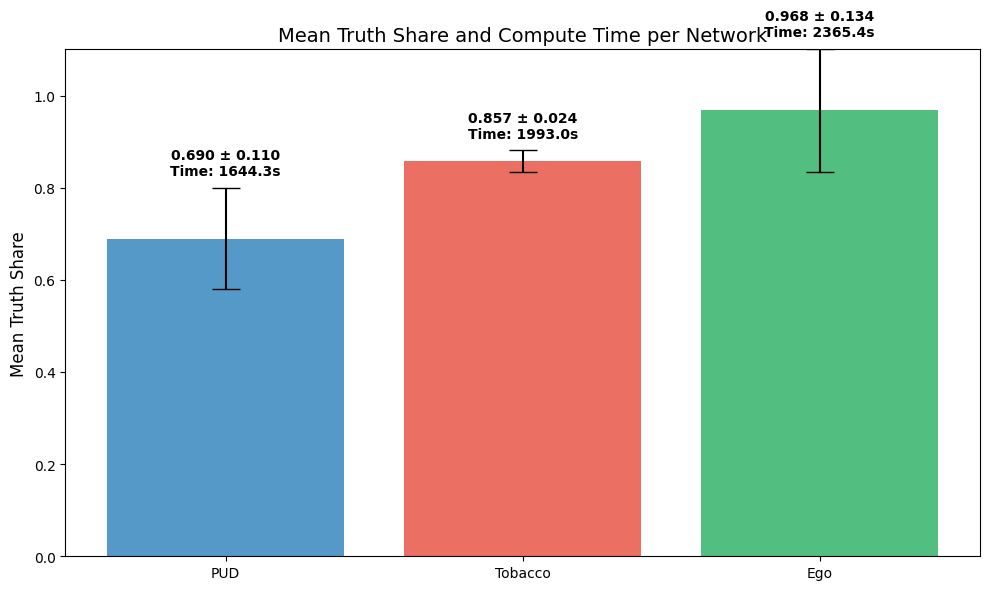

Plot saved to /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/compute_time_study_results.png


In [11]:
networks = ["PUD", "Tobacco", "Ego"]
means = [pud_mean, tobacco_mean, ego_mean]
stds = [pud_std, tobacco_std, ego_std]
times = [pud_time, tobacco_time, ego_time]
fig, ax1 = plt.subplots(figsize=(10, 6))
bars = ax1.bar(networks, means, yerr=stds, capsize=10, color=['#2980b9', '#e74c3c', '#27ae60'], alpha=0.8)
ax1.set_ylabel('Mean Truth Share', fontsize=12)
ax1.set_title('Mean Truth Share and Compute Time per Network', fontsize=14)
ax1.set_ylim(0, 1.1)  # slightly above 1 for text
for i, v in enumerate(means):
    ax1.text(i, v + stds[i] + 0.02, f"{v:.3f} ± {stds[i]:.3f}\nTime: {times[i]:.1f}s", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plot_path = dumping_path + "compute_time_study_results.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")


## Criterion Comparison: tolerance vs choice-stability

Both stopping criteria are **derived offline from the same 100,000-step runs** —
nothing is re-simulated. The tolerance stop comes from the snapshot series
(first step where max |Δcredence| falls below τ); the choice-stability stop
comes from the recorded flip history via `offline_stop`.

Because every run went the full 100k steps regardless, we can also see what each
criterion **missed**: the theory flips and the truth-share drift that happened
*after* it would have fired. That is the false-convergence failure mode the
choice-stability criterion was introduced to address, and it is only observable
in a run that refuses to stop.


In [12]:
# ── Criterion comparison config ──────────────────────────────────────────────
# Windows and tolerances match the other stopping-condition notebooks so the
# numbers are directly comparable across studies.
CS_WINDOWS   = [100, 500, 1000]
CS_MIN_STEPS = 10_000                     # the floor the choice-stability study uses
TOLERANCES   = [1e-3, 1e-4, 1e-5, 1e-6]


def offline_stop(flip_history, window, max_steps, min_steps=0):
    """Derive (stop_step, truth_share, stabilized) for a window from a
    record_choice_flips history [(step, truth_share), ...] — a baseline entry
    at run start plus one per step where >=1 agent flipped. Truth share is
    constant between flips, so the stop is fixed by the first flip-free
    interval long enough to contain `window` stable steps at or after
    `min_steps`. If none exists, the run did not stabilize within max_steps.

    Verbatim from `A. Choice Stability Stopping Study.ipynb` so both notebooks
    derive the criterion identically — if this ever diverges, the cross-study
    comparison silently stops being valid."""
    steps = [s for s, _ in flip_history] + [max_steps]
    shares = [t for _, t in flip_history]
    for i in range(len(flip_history)):
        candidate = max(steps[i] + window, min_steps)
        if candidate <= steps[i + 1]:
            return candidate, shares[i], True
    return max_steps, (shares[-1] if shares else np.nan), False


In [13]:
%%time
# ── Derive both criteria from the same runs ──────────────────────────────────
# One row per (network, run, criterion). `fired` distinguishes a genuine stop
# from a run that exhausted MAX_STEPS without ever satisfying the criterion —
# collapsing those two into "stopped at 100k" would silently censor the tail.
NETS = [("PUD", pud_snapshots, pud_flips),
        ("Tobacco", tobacco_snapshots, tobacco_flips),
        ("Ego", ego_snapshots, ego_flips)]

rows = []
for label, snaps, flips_all in NETS:
    for run_idx, (snap, flips) in enumerate(zip(snaps, flips_all)):
        steps = np.asarray(snap["step"])
        tshare = np.asarray(snap["truth_share"], dtype=float)
        change = np.asarray([np.nan if c is None else c
                             for c in snap["max_belief_change"]], dtype=float)
        final_truth = float(tshare[-1])

        def record(criterion, stop_step, truth_at_stop, fired):
            rows.append({
                "network": label, "run": run_idx, "criterion": criterion,
                "stop_step": stop_step,
                "truth_at_stop": truth_at_stop,
                "fired": int(fired),
                # The payoff of running to 100k: what the criterion missed.
                "post_stop_flips": sum(1 for s, _ in flips if s > stop_step),
                "final_truth": final_truth,
                "drift": final_truth - truth_at_stop,
                "total_flips": len(flips),
            })

        # (a) Choice-stability, with and without the 10k floor. The floor is
        #     binding for most runs in the choice-stability study, so the
        #     unfloored series is what isolates the criterion itself.
        for W in CS_WINDOWS:
            for floor, tag in ((0, ""), (CS_MIN_STEPS, "+floor")):
                stop, ts, stab = offline_stop(flips, W, MAX_STEPS, min_steps=floor)
                record(f"cs_W{W}{tag}", stop, ts, stab)

        # (b) Tolerance: first snapshot where max |Δcredence| < τ.
        #     NOTE snapshot resolution makes this an UPPER bound — the live
        #     criterion tests every step and may fire between two snapshots.
        #     Bias is at most SNAPSHOT_INTERVAL steps and is the same for every
        #     tolerance, so comparisons between tolerances stay fair.
        for tol in TOLERANCES:
            hit = np.flatnonzero(change < tol)
            if hit.size:
                j = int(hit[0])
                record(f"tol_{tol:.0e}", int(steps[j]), float(tshare[j]), True)
            else:
                record(f"tol_{tol:.0e}", MAX_STEPS, final_truth, False)

df_criteria = pd.DataFrame(rows)
df_criteria.to_csv(dumping_path + "criterion_comparison.csv", index=False)
print(f"{len(df_criteria)} rows: {df_criteria['criterion'].nunique()} criteria "
      f"x {len(NETS)} networks x {N_RUNS} runs")


15000 rows: 10 criteria x 3 networks x 500 runs
CPU times: user 17.5 s, sys: 92.2 ms, total: 17.6 s
Wall time: 17.6 s


── Stop step, truth share, and what each criterion missed ──
network      criterion  mean_stop  median_stop  fired_rate  truth_at_stop  final_truth  mean_drift  post_stop_flips
    Ego        cs_W100  17835.754      13679.5       1.000         0.8768       0.9679      0.0912         5796.998
    Ego  cs_W100+floor  20385.946      15247.5       1.000         0.8974       0.9679      0.0706         5243.294
    Ego       cs_W1000  56125.126      54519.5       0.896         0.9583       0.9679      0.0096         1015.524
    Ego cs_W1000+floor  56528.026      54585.5       0.896         0.9604       0.9679      0.0076          964.792
    Ego        cs_W500  41548.890      37999.5       0.974         0.9410       0.9679      0.0269         2055.588
    Ego  cs_W500+floor  42520.918      38332.0       0.974         0.9488       0.9679      0.0191         1902.846
    Ego      tol_1e-03    528.000        500.0       1.000         0.5816       0.9679      0.3863        14558.602
    Ego    

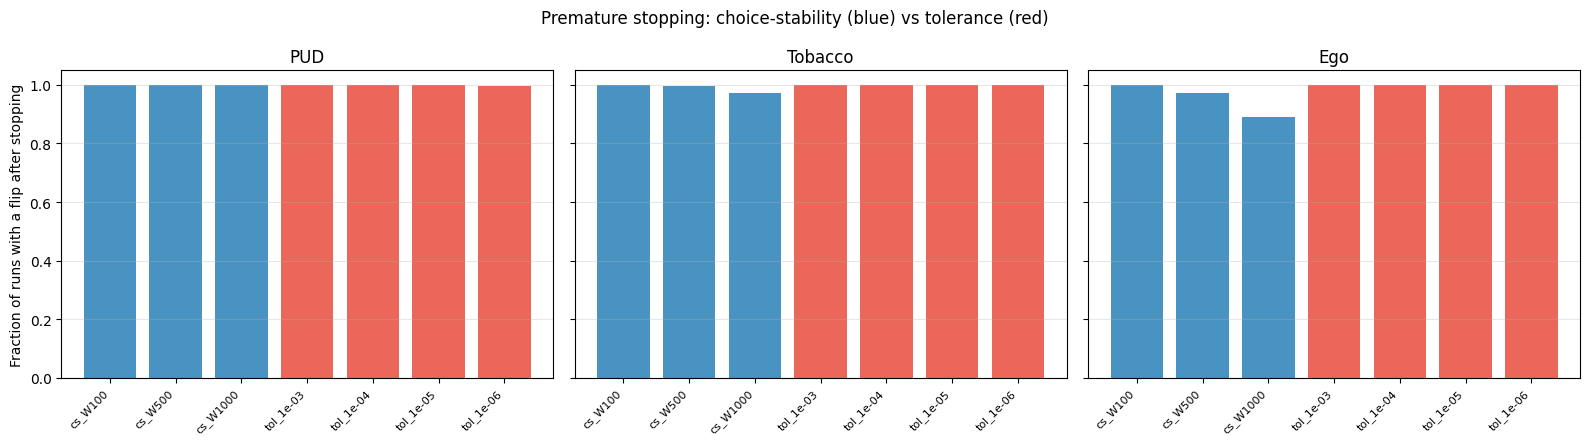

In [14]:
# ── Do the criteria disagree? ────────────────────────────────────────────────
summary = (df_criteria.groupby(["network", "criterion"])
           .agg(mean_stop=("stop_step", "mean"),
                median_stop=("stop_step", "median"),
                fired_rate=("fired", "mean"),
                truth_at_stop=("truth_at_stop", "mean"),
                final_truth=("final_truth", "mean"),
                mean_drift=("drift", "mean"),
                post_stop_flips=("post_stop_flips", "mean"))
           .round(4).reset_index())
print("── Stop step, truth share, and what each criterion missed ──")
print(summary.to_string(index=False))
summary.to_csv(dumping_path + "criterion_comparison_summary.csv", index=False)

# A criterion that stops while agents are still flipping is stopping early in
# the way that matters: the run had not settled, whatever the credences said.
print()
print("── Premature-stop rate (>=1 theory flip AFTER the criterion fired) ──")
prem = (df_criteria.assign(premature=(df_criteria.post_stop_flips > 0).astype(int))
        .groupby(["network", "criterion"])
        .agg(premature_rate=("premature", "mean"),
             mean_flips_after=("post_stop_flips", "mean"),
             mean_abs_drift=("drift", lambda s: s.abs().mean()))
        .round(4).reset_index())
print(prem.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
order = [f"cs_W{W}" for W in CS_WINDOWS] + [f"tol_{t:.0e}" for t in TOLERANCES]
for ax, (label, _, _) in zip(axes, NETS):
    sub = prem[(prem.network == label) & (prem.criterion.isin(order))]
    sub = sub.set_index("criterion").reindex(order)
    colors = ['#2980b9'] * len(CS_WINDOWS) + ['#e74c3c'] * len(TOLERANCES)
    ax.bar(range(len(order)), sub.premature_rate.values, color=colors, alpha=0.85)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha='right', fontsize=8)
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel("Fraction of runs with a flip after stopping")
fig.suptitle("Premature stopping: choice-stability (blue) vs tolerance (red)")
plt.tight_layout()
plt.savefig(dumping_path + "criterion_premature_stop.png", dpi=150,
            bbox_inches='tight')
plt.show()


## Snapshot Analysis: Belief Dynamics over Time

The following plots show the **average trajectory** across all 100 simulation runs for each network.

- **Left panel**: Mean truth share (± 1 SD) sampled every `SNAPSHOT_INTERVAL` steps.
- **Right panel**: Mean maximum absolute belief change (± 1 SD) on a log scale — a proxy for how quickly agents' beliefs have stabilised.


In [15]:
def aggregate_snapshots(all_snapshots):
    """
    Given a list of snapshot dicts (one per run), returns:
        steps              : 1-D array of step indices
        mean_truth         : mean truth share at each step
        std_truth          : std of truth share at each step
        mean_max_change    : mean of max-abs-belief-change at each step
        std_max_change     : std of max-abs-belief-change at each step
    """
    steps = np.array(all_snapshots[0]['step'])
    # Stack truth shares: shape (n_runs, n_steps)
    truth_matrix = np.array([s['truth_share'] for s in all_snapshots])
    # Stack max belief changes: filter None (bayes runs)
    change_lists = [s['max_belief_change'] for s in all_snapshots
                    if None not in s['max_belief_change']]
    change_matrix = np.array(change_lists) if change_lists else None

    mean_truth = truth_matrix.mean(axis=0)
    std_truth  = truth_matrix.std(axis=0)

    if change_matrix is not None:
        mean_change = change_matrix.mean(axis=0)
        std_change  = change_matrix.std(axis=0)
    else:
        mean_change = std_change = None

    return steps, mean_truth, std_truth, mean_change, std_change


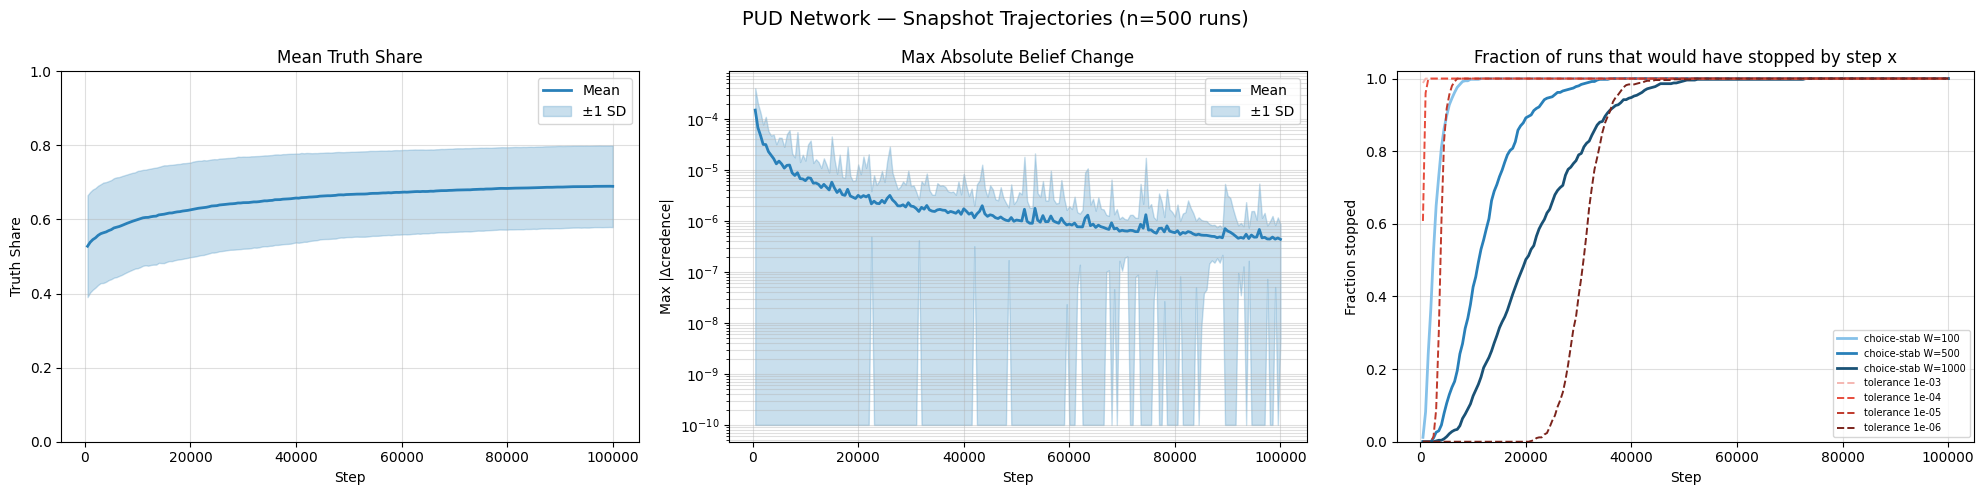

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/pud_snapshot_trajectories.png


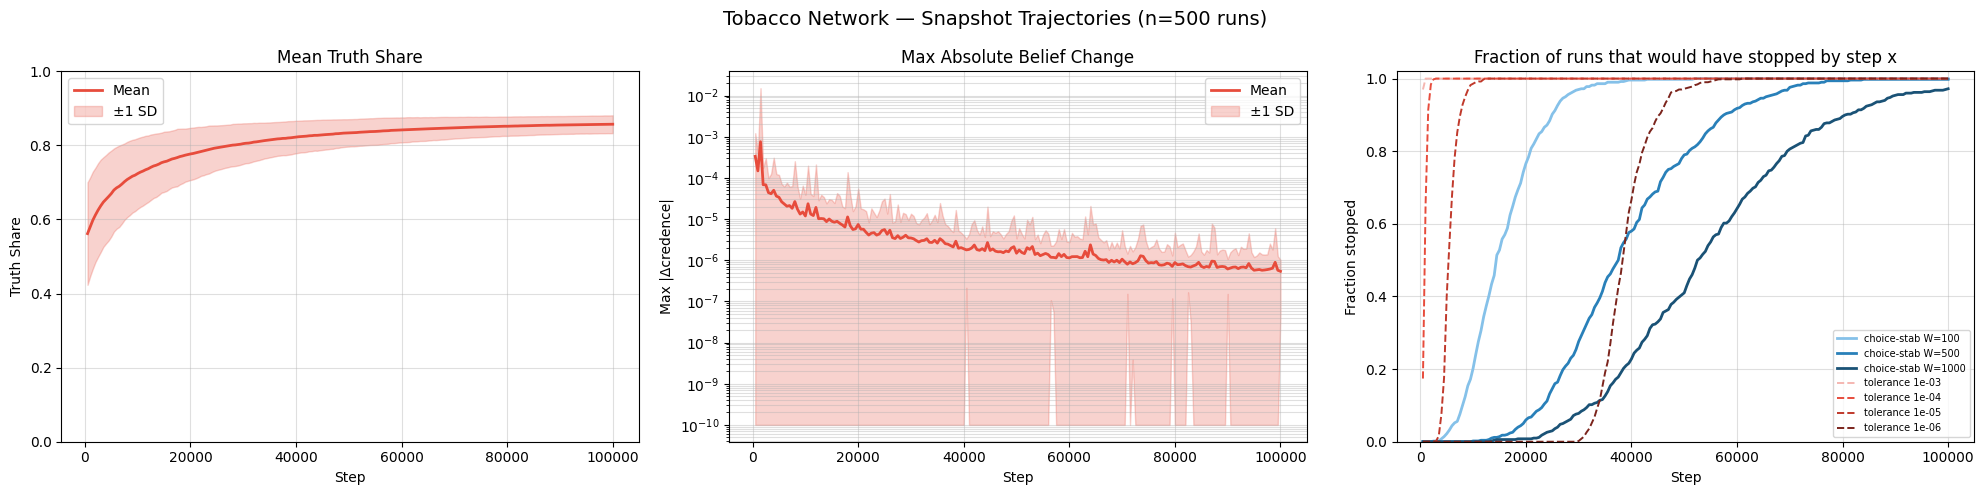

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/tobacco_snapshot_trajectories.png


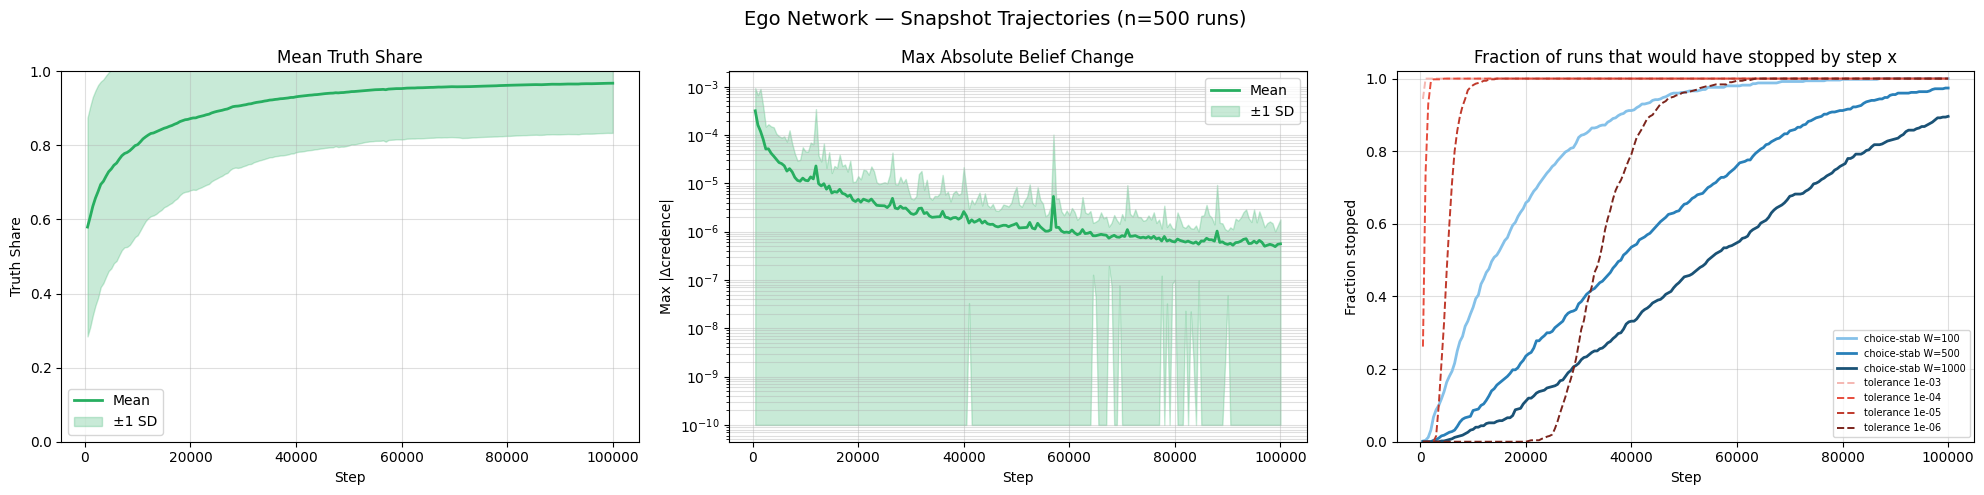

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/ego_snapshot_trajectories.png


In [16]:
# ── Per-network snapshot plots ─────────────────────────────────────────────
# Three panels per network:
#   1. mean truth share
#   2. mean max |Δcredence|  (the quantity tolerance stopping thresholds)
#   3. stop-time CDF — for each rule, the fraction of runs that WOULD have
#      stopped at or before step x. Panel 3 is what makes the criteria
#      comparable: two rules can reach the same truth share yet fire tens of
#      thousands of steps apart, and that gap is invisible in panels 1-2.
network_data = [
    ('PUD',     pud_snapshots,     '#2980b9'),
    ('Tobacco', tobacco_snapshots, '#e74c3c'),
    ('Ego',     ego_snapshots,     '#27ae60'),
]

# Blues = choice-stability (light -> dark as the window widens),
# reds = tolerance (light -> dark as the threshold tightens).
CS_COLORS  = ['#85c1e9', '#2980b9', '#1a5276']
TOL_COLORS = ['#f5b7b1', '#e74c3c', '#c0392b', '#7b241c']

for label, snaps, color in network_data:
    if not snaps:
        print(f'[{label}] No snapshots available.')
        continue

    steps, mt, st, mc, sc = aggregate_snapshots(snaps)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'{label} Network — Snapshot Trajectories (n={len(snaps)} runs)',
                 fontsize=14)

    # (1) truth share
    ax = axes[0]
    ax.plot(steps, mt, color=color, linewidth=2, label='Mean')
    ax.fill_between(steps, mt - st, mt + st, alpha=0.25, color=color, label='±1 SD')
    ax.set_title('Mean Truth Share')
    ax.set_xlabel('Step')
    ax.set_ylabel('Truth Share')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.4)

    # (2) max belief change
    ax = axes[1]
    if mc is not None:
        ax.plot(steps, mc, color=color, linewidth=2, label='Mean')
        ax.fill_between(steps, np.maximum(mc - sc, 1e-10), mc + sc,
                        alpha=0.25, color=color, label='±1 SD')
        ax.set_yscale('log')
        ax.set_title('Max Absolute Belief Change')
        ax.set_xlabel('Step')
        ax.set_ylabel('Max |Δcredence|')
        ax.legend()
        ax.grid(True, alpha=0.4, which='both')
    else:
        ax.set_visible(False)

    # (3) stop-time CDF per rule
    ax = axes[2]
    sub = df_criteria[df_criteria.network == label]
    for W, c in zip(CS_WINDOWS, CS_COLORS):
        d = sub[sub.criterion == f'cs_W{W}']
        # Runs that NEVER satisfied the rule must not count as stopped, so each
        # curve plateaus at its stabilization rate instead of reaching 1.0 —
        # the gap below 1.0 is the non-stabilization rate, which is a result,
        # not a plotting artifact.
        fired = np.sort(d.stop_step.values[d.fired.values == 1])
        cdf = np.searchsorted(fired, steps, side='right') / len(d)
        ax.plot(steps, cdf, color=c, linewidth=2, label=f'choice-stab W={W}')
    for tol, c in zip(TOLERANCES, TOL_COLORS):
        d = sub[sub.criterion == f'tol_{tol:.0e}']
        fired = np.sort(d.stop_step.values[d.fired.values == 1])
        cdf = np.searchsorted(fired, steps, side='right') / len(d)
        ax.plot(steps, cdf, color=c, linewidth=1.4, linestyle='--',
                label=f'tolerance {tol:.0e}')
    ax.set_title('Fraction of runs that would have stopped by step x')
    ax.set_xlabel('Step')
    ax.set_ylabel('Fraction stopped')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plot_path = dumping_path + f"{label.lower()}_snapshot_trajectories.png"
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f'Saved: {plot_path}')


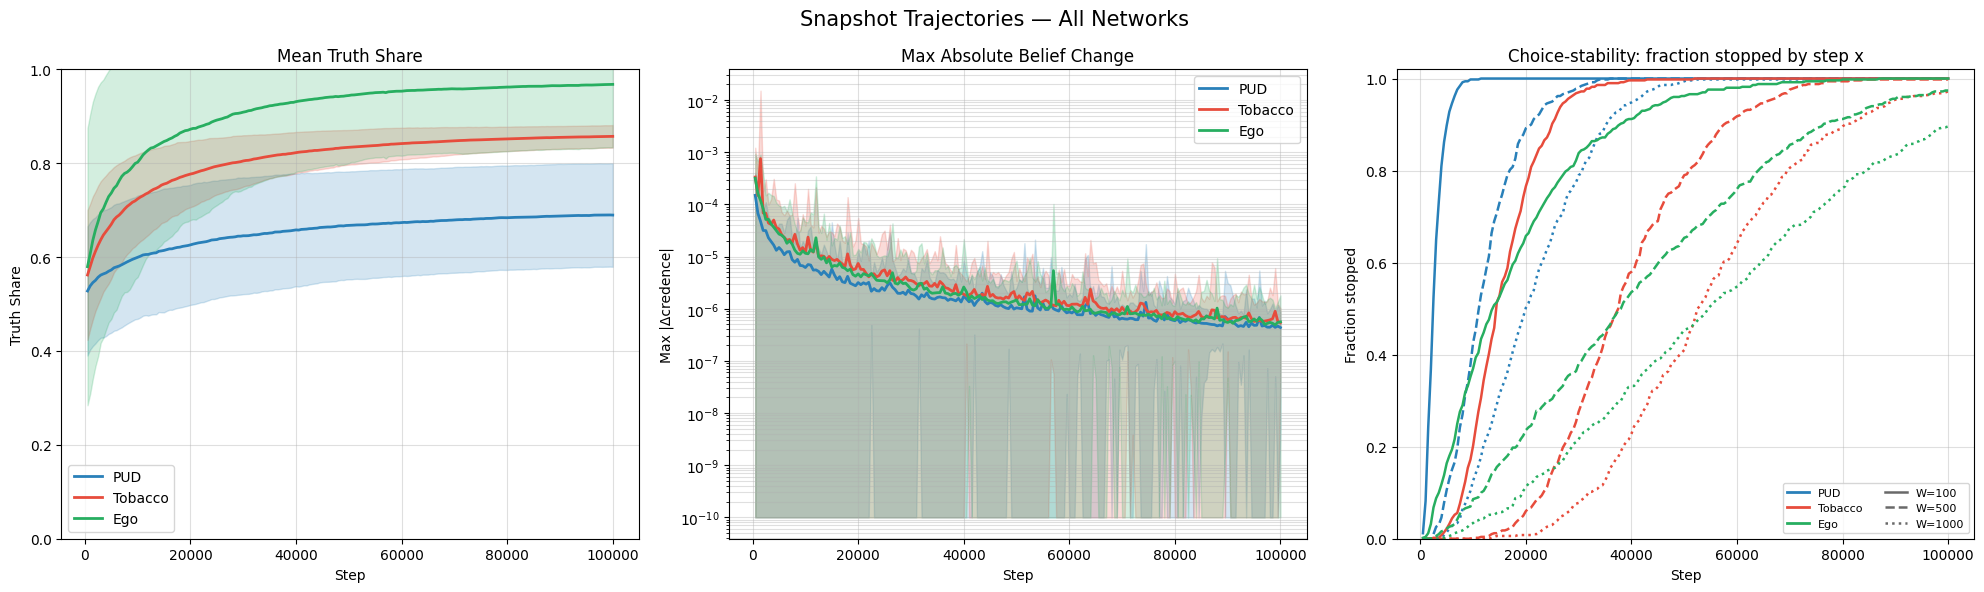

Saved: /content/drive/My Drive/Colab Projects/Data Driven ABMs/Data Sets/stop_condition_study/all_networks_snapshot_trajectories.png


In [17]:
# ── Combined comparison plot ────────────────────────────────────────────────
# Panel 3 encodes TWO variables at once: colour = network, line style = window.
# Tolerance curves are deliberately omitted here — 3 networks x 4 tolerances on
# top of this would be 21 lines. They are in the per-network panel above.
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Snapshot Trajectories — All Networks', fontsize=15)

network_data = [
    ('PUD',     pud_snapshots,     '#2980b9'),
    ('Tobacco', tobacco_snapshots, '#e74c3c'),
    ('Ego',     ego_snapshots,     '#27ae60'),
]
W_STYLES = dict(zip(CS_WINDOWS, ['-', '--', ':']))

for label, snaps, color in network_data:
    if not snaps:
        continue
    steps, mt, st, mc, sc = aggregate_snapshots(snaps)

    # Truth share
    axes[0].plot(steps, mt, color=color, linewidth=2, label=label)
    axes[0].fill_between(steps, mt - st, mt + st, alpha=0.2, color=color)

    # Max belief change
    if mc is not None:
        axes[1].plot(steps, mc, color=color, linewidth=2, label=label)
        axes[1].fill_between(steps, np.maximum(mc - sc, 1e-10), mc + sc,
                             alpha=0.2, color=color)

    # Stop-time CDF per choice-stability window
    sub = df_criteria[df_criteria.network == label]
    for W in CS_WINDOWS:
        d = sub[sub.criterion == f'cs_W{W}']
        fired = np.sort(d.stop_step.values[d.fired.values == 1])
        cdf = np.searchsorted(fired, steps, side='right') / len(d)
        axes[2].plot(steps, cdf, color=color, linewidth=1.8,
                     linestyle=W_STYLES[W])

axes[0].set_title('Mean Truth Share')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Truth Share')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].set_title('Max Absolute Belief Change')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Max |Δcredence|')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.4, which='both')

axes[2].set_title('Choice-stability: fraction stopped by step x')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Fraction stopped')
axes[2].set_ylim(0, 1.02)
axes[2].grid(True, alpha=0.4)
# Two-part legend: colour encodes network, dash pattern encodes window.
handles = [Line2D([], [], color=c, linewidth=2, label=n)
           for n, _, c in network_data]
handles += [Line2D([], [], color='dimgray', linestyle=W_STYLES[W],
                   linewidth=1.8, label=f'W={W}') for W in CS_WINDOWS]
axes[2].legend(handles=handles, fontsize=8, loc='lower right', ncol=2)

plt.tight_layout()
plot_path = dumping_path + 'all_networks_snapshot_trajectories.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved: {plot_path}')


## Disconnect from Runtime

In [18]:
from datetime import datetime
import pytz
from IPython.display import Javascript

# Get current time in New York
nyc_time = datetime.now(pytz.timezone('America/New_York'))
formatted_time = nyc_time.strftime('%Y-%m-%d %H:%M:%S %Z')

# Print and log
print(f"✅ Disconnected from runtime at: {formatted_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2026-07-19 08:34:12 EDT


<IPython.core.display.Javascript object>